# K-Nearest Neighbors (KNN) Regressor from Scratch

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Mock Data Generation

In [2]:
def generate_data(n_samples=150):
    X = np.random.rand(n_samples, 5) * 10
    
    y = 3*X[:, 0] + np.sin(X[:, 1]) * 5 + 0.1*X[:, 2]**2 + np.random.normal(0, 1, n_samples)
    
    columns = [f"Feature_{i+1}" for i in range(5)]
    df = pd.DataFrame(X, columns=columns)
    df['Target'] = y
    return df, X, y

df, X, y = generate_data()
df.head()

,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Target
0,6.650198,0.659656,3.044978,0.808771,1.093846,24.461828
1,5.349830,1.867579,9.051746,8.020094,0.058940,29.056887
2,7.199134,4.016260,1.635775,7.586832,0.246941,19.293248
3,6.813648,1.967900,1.794147,9.677221,6.967760,23.953648
4,7.506103,9.792140,7.732973,2.395465,6.327957,26.101707


## 2. Implementation

Euclidean Distance: $d(p, q) = \sqrt{\sum (p_i - q_i)^2}$

In [3]:
class KNNRegressorScratch:
    def __init__(self, k=3):
        self.k = k
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        # KNN is a lazy learner, it just stores the training data
        self.X_train = X
        self.y_train = y

    def _euclidean_distance(self, x1, x2):
        return np.sqrt(np.sum((x1 - x2) ** 2))

    def predict(self, X):
        y_pred = [self._predict(x) for x in X]
        return np.array(y_pred)

    def _predict(self, x):
        # 1. Compute distances between x and all examples in training set
        distances = [self._euclidean_distance(x, x_train) for x_train in self.X_train]
        
        # 2. Sort distances and return indices of first k neighbors
        k_indices = np.argsort(distances)[:self.k]
        
        # 3. Extract the target values of the k nearest neighbor training samples
        k_nearest_labels = [self.y_train[i] for i in k_indices]
        
        # 4. Return the mean of these labels
        return np.mean(k_nearest_labels)

## 3. Training and Visualization

MSE: 12.3987


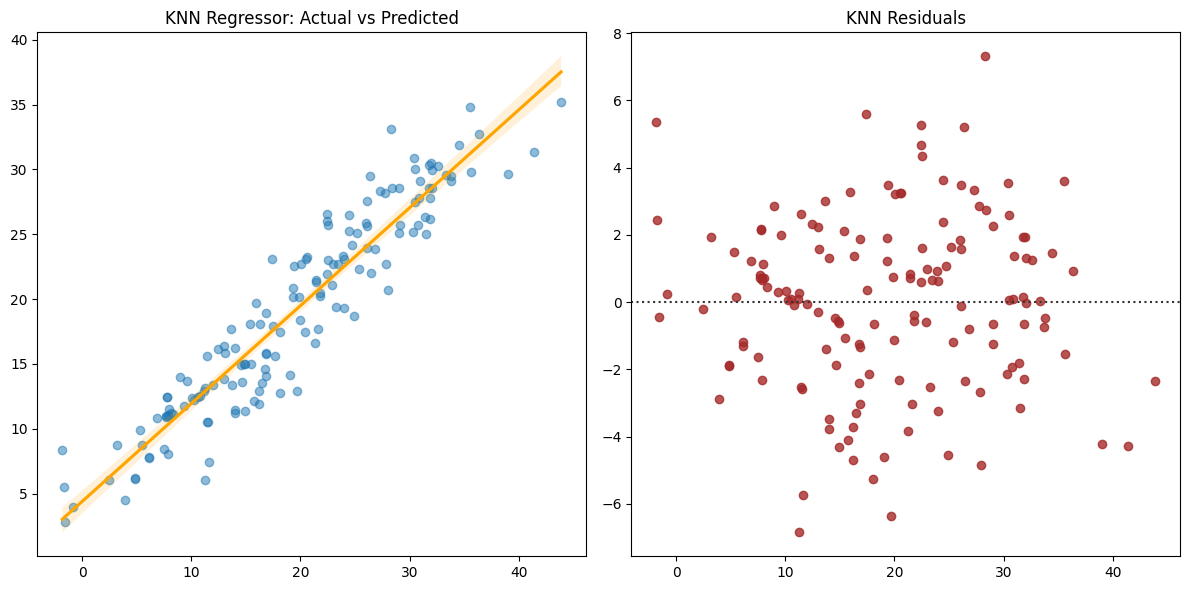

In [4]:
model = KNNRegressorScratch(k=5)
model.fit(X, y)

y_pred = model.predict(X)
print(f"MSE: {np.mean((y - y_pred)**2):.4f}")

plt.figure(figsize=(12, 6))

# Actual vs Predicted Scatter
plt.subplot(1, 2, 1)
sns.regplot(x=y, y=y_pred, scatter_kws={'alpha':0.5}, line_kws={'color':'orange'})
plt.title("KNN Regressor: Actual vs Predicted")

# Residual Plot
plt.subplot(1, 2, 2)
sns.residplot(x=y, y=y_pred, color="brown")
plt.title("KNN Residuals")

plt.tight_layout()
plt.show()